<a href="https://colab.research.google.com/github/Sergiu-Boris/Plant-health-recognition-algorithm/blob/main/AI_Project_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI PROJECT: A PLANT DEASEASE DETECTOR

Hola, questo è quello che ho fatto fino ad ora, mano a mano aggiorno da qui in giu xoxo

ps per comodità sto lavorando con le cartelle caricate su google drive. quindi ho montato il drive su collab (altrimenti ogni disconnessione ci mette una vita a caricarle)

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


Dani

In [ ]:
!unzip -o '/content/drive/MyDrive/AI_PROJECT/dataset2.zip'


Streaming output truncated to the last 5000 lines.
  inflating: PlantVillage/val/Soybean___healthy/52c7d07b-561b-4380-801a-3824e65a5135___RS_HL 3797.JPG  
  inflating: PlantVillage/val/Soybean___healthy/53168d1c-ac90-4039-9eff-7479475a6b74___RS_HL 6355.JPG  
  inflating: PlantVillage/val/Soybean___healthy/5344b09f-bbbe-4a2c-9345-d93dd4e69eb4___RS_HL 4693.JPG  
  inflating: PlantVillage/val/Soybean___healthy/5361ba4a-351e-466c-99c5-8845f35c00df___RS_HL 2890.JPG  
  inflating: PlantVillage/val/Soybean___healthy/537e5409-d824-4859-967f-3c502f13deec___RS_HL 5474.JPG  
  inflating: PlantVillage/val/Soybean___healthy/538969da-545b-4bce-bc1d-0932898dc5e6___RS_HL 5230.JPG  
  inflating: PlantVillage/val/Soybean___healthy/538ccfe2-1509-40d7-beae-ae7cf84e1e5d___RS_HL 3717.JPG  
  inflating: PlantVillage/val/Soybean___healthy/5397bf6a-aeeb-4f1c-b554-bdb604bb23c3___RS_HL 6508.JPG  
  inflating: PlantVillage/val/Soybean___healthy/53dc0466-621c-43e1-9c5e-e340f3d50171___RS_HL 6381.JPG  
  inflating: 

In [ ]:
# Set directories
val_dir= '/content/PlantVillage/val'

train_dir='/content/PlantVillage/train'

Anto

In [ ]:
# Unzip validation dataset
!unzip '/content/drive/MyDrive/ANNO1/QUARTO PERIODO/DATA ANALYTICS AND ARTIFICIAL INTELLIGENCE 2/PROJECT/val_1.zip'

# Unzip training dataset
!unzip '/content/drive/MyDrive/ANNO1/QUARTO PERIODO/DATA ANALYTICS AND ARTIFICIAL INTELLIGENCE 2/PROJECT/train_1.zip'

# Set directories
val_dir= '/content/val'

train_dir='/content/train'

unzip:  cannot find or open /content/drive/MyDrive/ANNO1/QUARTO PERIODO/DATA ANALYTICS AND ARTIFICIAL INTELLIGENCE 2/PROJECT/val_1.zip, /content/drive/MyDrive/ANNO1/QUARTO PERIODO/DATA ANALYTICS AND ARTIFICIAL INTELLIGENCE 2/PROJECT/val_1.zip.zip or /content/drive/MyDrive/ANNO1/QUARTO PERIODO/DATA ANALYTICS AND ARTIFICIAL INTELLIGENCE 2/PROJECT/val_1.zip.ZIP.
unzip:  cannot find or open /content/drive/MyDrive/ANNO1/QUARTO PERIODO/DATA ANALYTICS AND ARTIFICIAL INTELLIGENCE 2/PROJECT/train_1.zip, /content/drive/MyDrive/ANNO1/QUARTO PERIODO/DATA ANALYTICS AND ARTIFICIAL INTELLIGENCE 2/PROJECT/train_1.zip.zip or /content/drive/MyDrive/ANNO1/QUARTO PERIODO/DATA ANALYTICS AND ARTIFICIAL INTELLIGENCE 2/PROJECT/train_1.zip.ZIP.


For model evaluation we need three subsets:


*   Training Set: to train the model
*   Validation Set: to tune hyperparameters and check for overfitting under training.
*   Test Set: to evaluate the model's performance on completely unseen data.

The dataset provides only two splits: *train* and *val*.

Then the validation set is further split into:

*  A smaller validation subset
*  A test subset

A function (*split_data*) is created to perform the split, which by default assigns 20% of each class to the test set and 80% to the validation set.

In [ ]:
import os
import shutil
import random

#Define paths for the new subdirectories
val_dir_original = val_dir
val_dir_new= os.path.join(val_dir_original,'val') #new subdirectory for validation
test_dir= os.path.join(val_dir_original,'test') #new subdirectory for test

#Create the new subdirectories
os.makedirs(val_dir_new, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# Function to split data into subdirectories
def split_data(source_dir, val_dir, test_dir, test_split=0.2):

    """Splits data into validation and test subdirectories.

    Args:
        source_dir: Path to the source directory containing class folders.
        val_dir: Path to the validation subdirectory.
        test_dir: Path to the test subdirectory.
        test_split: Fraction of data to use for testing (default: 0.2).

    """

    #Get a list of all items (files and directories)
    all_items= os.listdir(source_dir)

    #Filter out 'test' and 'val' from the list of items to process
    class_names= [item for item in all_items if item not in ('test', 'val')]

    #Iterate through filtered class names
    for class_name in class_names:
        class_dir = os.path.join(source_dir, class_name) #path to access the specific directory
        if os.path.isdir(class_dir):
            images = os.listdir(class_dir)
            random.shuffle(images)
            split_index = int(len(images) * (1 - test_split))
            val_images = images[:split_index]
            test_images = images[split_index:]

            for image in val_images:
                src_path = os.path.join(class_dir, image)
                dest_path = os.path.join(val_dir, class_name, image)
                os.makedirs(os.path.dirname(dest_path), exist_ok=True)  # Create class folder in val_dir
                shutil.copy(src_path, dest_path)

            for image in test_images:
                src_path = os.path.join(class_dir, image) #where to find the image
                dest_path = os.path.join(test_dir, class_name, image) #where i want it to be
                os.makedirs(os.path.dirname(dest_path), exist_ok=True)  # Create class folder in test_dir
                shutil.copy(src_path, dest_path) #copy/paste

# Split the validation data into val and test subdirectories
split_data(val_dir_original, val_dir_new, test_dir, test_split=0.2)

sec me possiamo iniziare provando a fare un CNN molto semplice senza pre-training (praticamente come fatto con il prof, lo costruiamo da scratch), vedere come performa e poi utilizzare altri modelli gia pre-trained come ResNet50

In [ ]:
# Imports
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt

# 2. Image Data Generators
train_datagen = ImageDataGenerator(rescale=1.0/255.0)

val_datagen = ImageDataGenerator(rescale=1.0/255.0)


# 3. Creating Train, Validation and Test Generators
batch_size = 32
img_size = (224, 224) #target size for the images

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir_new,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

test_generator = val_datagen.flow_from_directory(
    test_dir,  # Use the new test subdirectory
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

# Define number of classes based on dataset structure
num_classes = len(val_generator.class_indices)  # Number of classes from data generator

# Define name of the classes (labels)
class_names=list(val_generator.class_indices.keys())
print(class_names)


print(val_generator.class_indices)

Found 43444 images belonging to 38 classes.
Found 8676 images belonging to 38 classes.
Found 2185 images belonging to 38 classes.
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_

In [ ]:
# modello con filtri piu bassi
from tensorflow.keras import models, layers, regularizers
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.layers import Dense,Conv2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from keras.optimizers import Adam

# Define callbacks
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath='model_epoch_{epoch:02d}.keras',
    save_best_only=False,
    save_weights_only=False,
    save_freq='epoch')
early_stopping_callback = tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
#early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
#model_checkpoint = ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)


# Define model
class_count = len(list(train_generator.class_indices.keys()))
input_shape = (224, 224, 3)

plant_model = models.Sequential([
    layers.Input(shape=input_shape), # Define input shape here

    layers.Conv2D(16, (3, 3), activation='relu', kernel_regularizer = regularizers.l2(0.001)),
    BatchNormalization(),
    layers.MaxPooling2D((2, 2)),



    layers.Conv2D(32, (3, 3), activation='relu', kernel_regularizer = regularizers.l2(0.001)),
    BatchNormalization(),
    layers.MaxPooling2D((2, 2)),


    layers.Conv2D(64, (3, 3), activation='relu', kernel_regularizer = regularizers.l2(0.001)),
    BatchNormalization(),
    layers.MaxPooling2D((2, 2)),


    layers.Flatten(),

    layers.Dense(128, activation='relu', kernel_regularizer = regularizers.l2(0.0001)),
    layers.Dense(class_count, activation='softmax'),
])


plant_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 43264)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     5,537,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,566,854 (21.24 MB)

 Trainable params: 5,566,630 (21.24 MB)

 Non-trainable params: 224 (896.00 B)

In [ ]:
plant_model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = plant_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[early_stopping_callback, checkpoint_callback, reduce_lr]
)

Epoch 1/15


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 105s 71ms/step - accuracy: 0.6485 - loss: 1.4245 - val_accuracy: 0.8453 - val_loss: 0.6447 - learning_rate: 1.0000e-04
Epoch 2/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 145s 77ms/step - accuracy: 0.9122 - loss: 0.3803 - val_accuracy: 0.8744 - val_loss: 0.5384 - learning_rate: 1.0000e-04
Epoch 3/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 97s 71ms/step - accuracy: 0.9596 - loss: 0.2215 - val_accuracy: 0.8670 - val_loss: 0.6254 - learning_rate: 1.0000e-04
Epoch 4/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 84s 62ms/step - accuracy: 0.9734 - loss: 0.1795 - val_accuracy: 0.8858 - val_loss: 0.5686 - learning_rate: 1.0000e-04
Epoch 5/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 94s 69ms/step - accuracy: 0.9834 - loss: 0.1526 - val_accuracy: 0.8836 - val_loss: 0.6019 - learning_rate: 1.0000e-04
Epoch 6/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 97s 72ms/step - accuracy: 0.9943 - loss: 0.1210 - val_accuracy: 0.9269 - val_loss: 0.3939 - learning_rate: 2.0000e-05
Epoch 7/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 148s 76

Definition of a function for plotting the training and validation accuracy and loss.

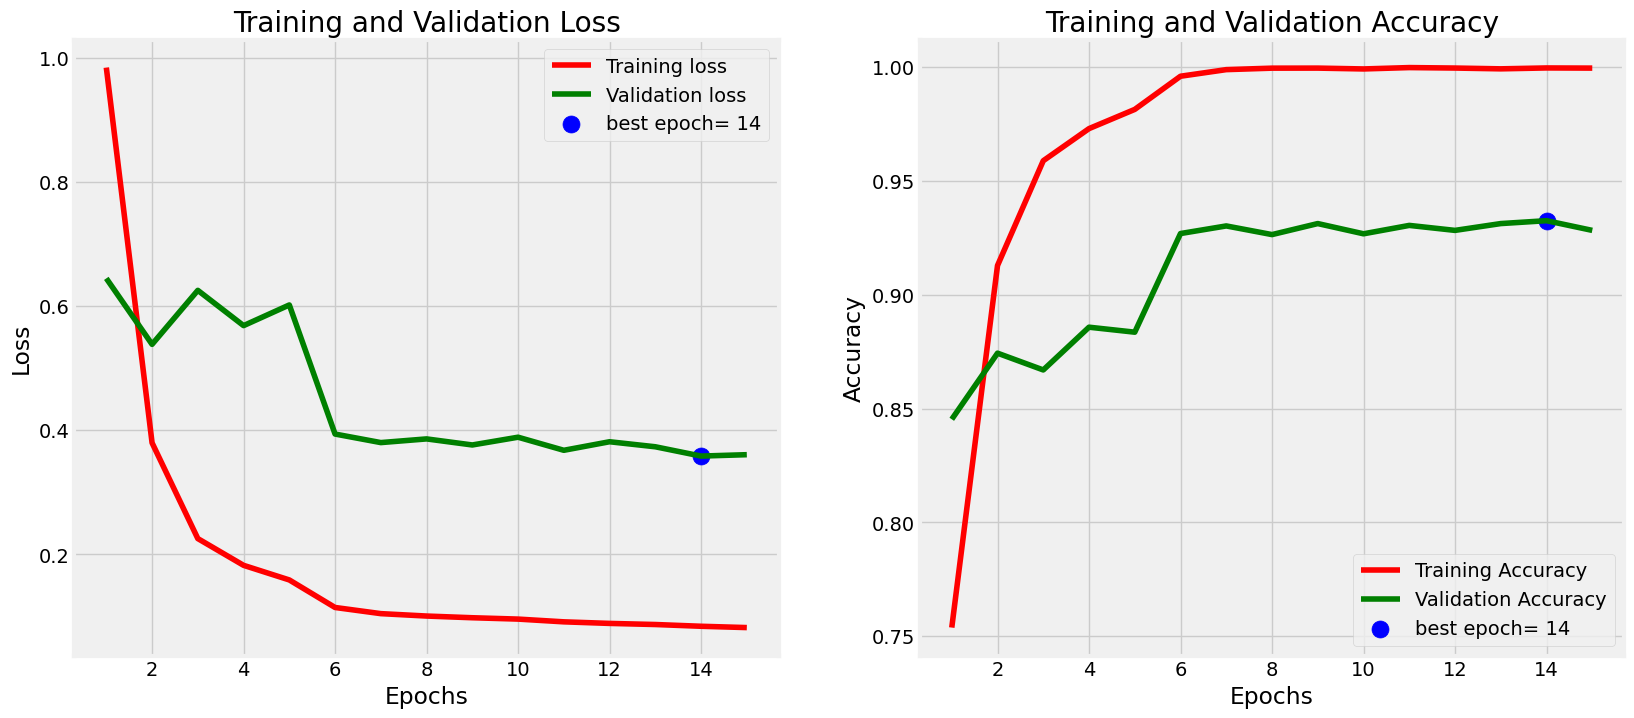

In [ ]:
import numpy as np

def plot_training(hist):


    # Define needed variables
    tr_acc = hist.history['accuracy']
    tr_loss = hist.history['loss']
    val_acc = hist.history['val_accuracy']
    val_loss = hist.history['val_loss']

    index_loss = np.argmin(val_loss)
    val_lowest = val_loss[index_loss]
    index_acc = np.argmax(val_acc)
    acc_highest = val_acc[index_acc]

    Epochs = [i+1 for i in range(len(tr_acc))]

    loss_label = f'best epoch= {str(index_loss + 1)}'
    acc_label = f'best epoch= {str(index_acc + 1)}'

    # Plot training history
    plt.figure(figsize= (20, 8))
    plt.style.use('fivethirtyeight')

    plt.subplot(1, 2, 1)
    plt.plot(Epochs, tr_loss, 'r', label= 'Training loss')
    plt.plot(Epochs, val_loss, 'g', label= 'Validation loss')
    plt.scatter(index_loss + 1, val_lowest, s= 150, c= 'blue', label= loss_label)
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(Epochs, tr_acc, 'r', label= 'Training Accuracy')
    plt.plot(Epochs, val_acc, 'g', label= 'Validation Accuracy')
    plt.scatter(index_acc + 1 , acc_highest, s= 150, c= 'blue', label= acc_label)
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout
    plt.show()


plot_training(history)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

#loading best weights
#plant_model.load_weights('best_model.keras')

#evaluating on the test set: no need to specify batches, length, or steps since the generator contains already all the info; verbose=1 (default) printa tutte le info; v=0 niente; v=2 solo i results
test_score=plant_model.evaluate(test_generator)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

#fancy way to write it directly in percentage terms and rounding to the second decimal
#print(f"Test Accuracy: {test_score[1]* 100:.2f}%")


 1/69 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - accuracy: 0.9062 - loss: 0.8066

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - accuracy: 0.9317 - loss: 0.3908
Test Loss:  0.37317824363708496
Test Accuracy:  0.9368420839309692


In [ ]:
class_dict = test_generator.class_indices
labels = list(class_dict.keys())

# Reset the test generator to ensure same ordering
test_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

test_generator.reset()

# Make predictions: running the model on test set, 2D array with predicted proabilities for each image
preds = plant_model.predict(test_generator)

# Get the predicted class indices (highest probability): it finds the highest value along columns and returns the corresponding index
y_pred = np.argmax(preds, axis=1)

# Print the predicted class, confidence score, and human-readable label
for i in range(len(y_pred)):
    predicted_class = y_pred[i]  # Get the predicted class index for this image
    confidence_score = preds[i][predicted_class]  # Get the confidence score for that class

    # Print the results for this image
    print(f'Image {i+1}: Predicted Class: {labels[predicted_class]}, Confidence Score: {confidence_score:.4f}')

Found 2185 images belonging to 38 classes.
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step
Image 1: Predicted Class: Apple___Apple_scab, Confidence Score: 0.7186
Image 2: Predicted Class: Apple___Apple_scab, Confidence Score: 0.9969
Image 3: Predicted Class: Apple___Apple_scab, Confidence Score: 0.9999
Image 4: Predicted Class: Apple___Apple_scab, Confidence Score: 0.9985
Image 5: Predicted Class: Apple___Apple_scab, Confidence Score: 0.9999
Image 6: Predicted Class: Apple___Cedar_apple_rust, Confidence Score: 0.8134
Image 7: Predicted Class: Potato___Late_blight, Confidence Score: 0.9199
Image 8: Predicted Class: Apple___Apple_scab, Confidence Score: 0.9950
Image 9: Predicted Class: Apple___Apple_scab, Confidence Score: 0.9992
Image 10: Predicted Class: Apple___Apple_scab, Confidence Score: 1.0000
Image 11: Predicted Class: Apple___Apple_scab, Confidence Score: 0.9998
Image 12: Predicted Class: Apple___Apple_scab, Confidence Score: 0.9715
Image 13: Predicted Class: Apple___Apple_scab, Confide

In [ ]:
print(test_generator.classes)
print(y_pred)

# Print a few predictions and true labels
for i in range(10):  # Print the first 10 predictions
    print(f"Prediction: {labels[y_pred[i]]}, True Label: {labels[test_generator.classes[i]]}")

[ 0  0  0 ... 37 37 37]
[ 0  0  0 ... 37 37 37]
Prediction: Apple___Apple_scab, True Label: Apple___Apple_scab
Prediction: Apple___Apple_scab, True Label: Apple___Apple_scab
Prediction: Apple___Apple_scab, True Label: Apple___Apple_scab
Prediction: Apple___Apple_scab, True Label: Apple___Apple_scab
Prediction: Apple___Apple_scab, True Label: Apple___Apple_scab
Prediction: Apple___Cedar_apple_rust, True Label: Apple___Apple_scab
Prediction: Potato___Late_blight, True Label: Apple___Apple_scab
Prediction: Apple___Apple_scab, True Label: Apple___Apple_scab
Prediction: Apple___Apple_scab, True Label: Apple___Apple_scab
Prediction: Apple___Apple_scab, True Label: Apple___Apple_scab


In [ ]:
# Classification report
# The classification_report() function generates a detailed report on the performance, it includes 3 metrics: precision, recall, and F1-score.
# It compares model's predictions with the true labels.
print(classification_report(test_generator.classes, y_pred, target_names= labels))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.73      0.73      0.73        26
                                 Apple___Black_rot       0.92      0.88      0.90        25
                          Apple___Cedar_apple_rust       0.82      0.82      0.82        11
                                   Apple___healthy       0.93      0.94      0.93        66
                               Blueberry___healthy       0.95      1.00      0.98        60
          Cherry_(including_sour)___Powdery_mildew       0.93      1.00      0.97        42
                 Cherry_(including_sour)___healthy       1.00      0.97      0.99        34
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.75      0.57      0.65        21
                       Corn_(maize)___Common_rust_       0.98      1.00      0.99        48
               Corn_(maize)___Northern_Leaf_Blight       0.80      0.90      0.

Confusion Matrix:
[[ 19   0   1 ...   0   0   0]
 [  2  22   0 ...   0   0   0]
 [  0   0   9 ...   0   0   0]
 ...
 [  0   0   0 ... 210   0   0]
 [  0   0   0 ...   0  13   0]
 [  0   0   0 ...   0   0  63]]


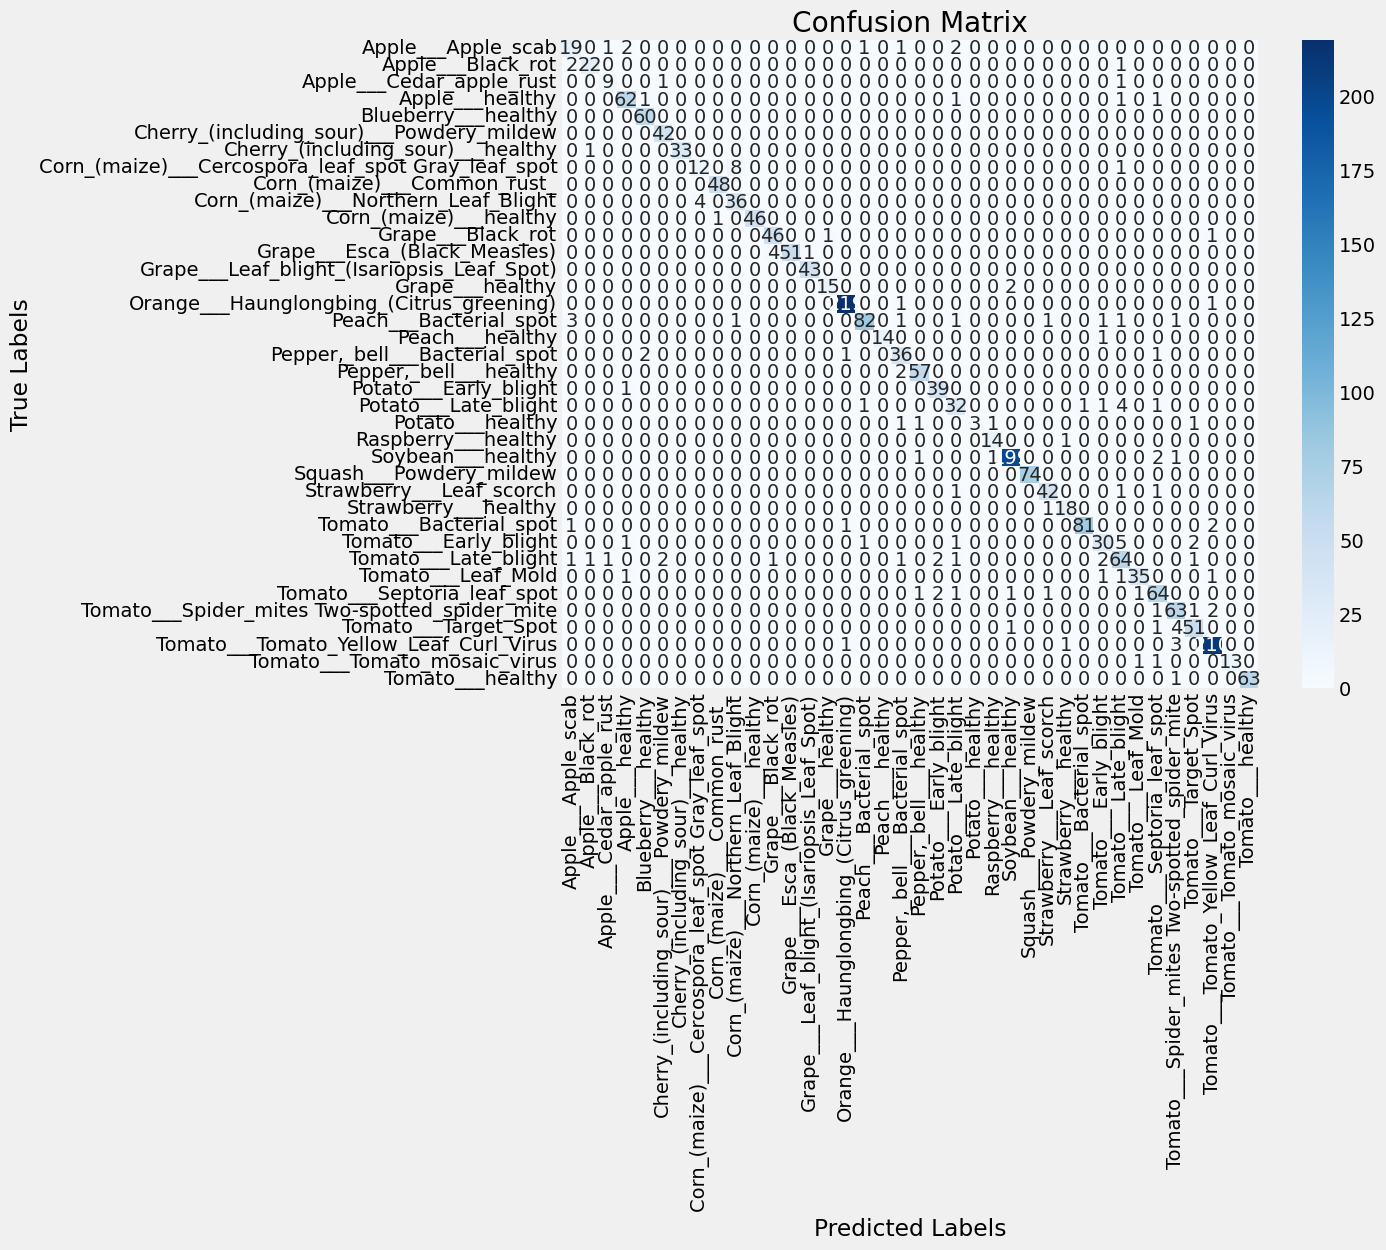

In [ ]:
import seaborn as sns
import pandas as pd

# Confusion Matrix
print("Confusion Matrix:")
conf_matrix = confusion_matrix(test_generator.classes, y_pred)
print(conf_matrix)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Save directly to Google Drive
#plant_model.save('/content/drive/MyDrive/plant_disease_detector.keras')

# PRE-TRAINED MODEL

ResNet50

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')
!unzip -o '/content/drive/MyDrive/AI_PROJECT/dataset2.zip'

Mounted at /content/drive/
'01a66316-0e98-4d3b-a56f-d78752cd043f___FREC_Scab 3003.JPG'
'01f3deaa-6143-4b6c-9c22-620a46d8be04___FREC_Scab 3112.JPG'
'0208f4eb-45a4-4399-904e-989ac2c6257c___FREC_Scab 3037.JPG'
'023123cb-7b69-4c9f-a521-766d7c8543bb___FREC_Scab 3487.JPG'
'0261a6e4-21f8-481a-8827-b674e6955644___FREC_Scab 3055.JPG'
'029424b0-0ef5-491b-9ef5-069190d24d8f___FREC_Scab 3504.JPG'
'0340dc35-5215-48ab-8db7-06af99fcb358___FREC_Scab 2966.JPG'
'03eccb1a-0368-4ac7-9f48-7546037b775a___FREC_Scab 3334.JPG'
'0537ad56-3d24-4e97-a947-65b9b37f8988___FREC_Scab 3079.JPG'


ResNet50 code ran on local machine due to high computational requirements

In [ ]:
# Import required packages
import csv
from datetime import datetime
import matplotlib.pyplot as plt
from pathlib import Path
import torch
from torch import nn, optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from tqdm import tqdm


# Set parameters for trasforming the images used to implement the model according to ImageNet
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


# Setting up training and validation directories containing the files
train_dir = 'C:\\Users\\Sergiu\\OneDrive - unive.it\\Desktop\\AI_PROJECT\\PlantVillage\\train'
val_dir = 'C:\\Users\\Sergiu\\OneDrive - unive.it\\Desktop\\AI_PROJECT\\PlantVillage\\val'


train_dataset = datasets.ImageFolder(root= train_dir, transform=transform)
val_dataset = datasets.ImageFolder(root= val_dir, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)


model = models.resnet50(weights="IMAGENET1K_V1")

num_classes = len(train_dataset.classes)
model.fc = nn.Linear(model.fc.in_features, num_classes)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

def train_model(model, train_loader, val_loader, device, num_epochs=10, learning_rate=1e-4):
    # Create CSV file with timestamp
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    csv_file = f'training_metrics_{timestamp}.csv'

    # Write CSV header
    with open(csv_file, mode='w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['Epoch', 'Train Loss', 'Train Acc', 'Val Loss', 'Val Acc', 'Best Val Acc'])

    best_val_acc = 0
    train_accuracies = []
    val_accuracies = []
    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        # Training phase
        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        # Calculate training metrics
        train_acc = correct / total
        epoch_train_loss = running_loss / len(train_loader)
        train_losses.append(epoch_train_loss)
        train_accuracies.append(train_acc)

        # Validation phase
        model.eval()
        val_correct = 0
        val_total = 0
        val_running_loss = 0.0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_running_loss += loss.item()

                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

        # Calculate validation metrics
        val_acc = val_correct / val_total
        epoch_val_loss = val_running_loss / len(val_loader)
        val_losses.append(epoch_val_loss)
        val_accuracies.append(val_acc)

        # Update best validation accuracy
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'best_model.pth')

        # Print metrics
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print(f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {val_acc:.4f}")
        print(f"Best Val Acc: {best_val_acc:.4f}")

        # Save metrics to CSV after each epoch
        with open(csv_file, mode='a', newline='') as f:
            writer = csv.writer(f)
            writer.writerow([
                epoch+1,
                f"{epoch_train_loss:.4f}",
                f"{train_acc:.4f}",
                f"{epoch_val_loss:.4f}",
                f"{val_acc:.4f}",
                f"{best_val_acc:.4f}"
            ])

    # Final plots
    plt.figure(figsize=(15,5))

    plt.subplot(1,2,1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.title("Loss Curves")
    plt.xlabel("Epoch")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(train_accuracies, label='Train Acc')
    plt.plot(val_accuracies, label='Val Acc')
    plt.title("Accuracy Curves")
    plt.xlabel("Epoch")
    plt.legend()

    plt.tight_layout()
    plt.show()

    print(f"\nTraining complete! Metrics saved to {csv_file}")
    return train_losses, train_accuracies, val_losses, val_accuracies

# Run training
train_losses, train_accuracies, val_losses, val_accuracies = train_model(
    model, train_loader, val_loader, device, num_epochs=6, learning_rate=1e-4
)

Plot Trainign History

In [ ]:
import matplotlib.pyplot as plt
import torch
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import os

import torch
from torch import nn, optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import csv


results_path = 'C:\\Users\\Sergiu\\OneDrive - unive.it\\Desktop\\AI_PROJECT\\training_metrics_20250521_002145.csv'


def parse_training_metrics(csv_file_path):
    epochs_data = []

    with open(csv_file_path, mode='r') as csv_file:
        csv_reader = csv.DictReader(csv_file)
        for row in csv_reader:
            # Convert numeric values from strings to appropriate types
            epoch_data = {
                'Epoch': int(row['Epoch']),
                'Train Loss': float(row['Train Loss']),
                'Train Acc': float(row['Train Acc']),
                'Val Loss': float(row['Val Loss']),
                'Val Acc': float(row['Val Acc']),
                'Best Val Acc': float(row['Best Val Acc'])
            }
            epochs_data.append(epoch_data)

    return epochs_data

parsed_data = parse_training_metrics(results_path)
train_losses = [data['Train Loss'] for data in parsed_data]
val_losses = [data['Val Loss'] for data in parsed_data]
train_accuracies = [data['Train Acc'] for data in parsed_data]
val_accuracies = [data['Val Acc'] for data in parsed_data]

# Print the parsed data for verification
for data in parsed_data:
    print(f"Epoch: {data['Epoch']}, Train Loss: {data['Train Loss']}, Train Acc: {data['Train Acc']}, Val Loss: {data['Val Loss']}, Val Acc: {data['Val Acc']}, Best Val Acc: {data['Best Val Acc']}")

# Metrics plotting
def plot_training_history(train_losses, val_losses, train_accuracies, val_accuracies):
    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(14, 5))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, 'bo-', label='Training Loss')
    plt.plot(epochs, val_losses, 'ro-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, 'bo-', label='Training Accuracy')
    plt.plot(epochs, val_accuracies, 'ro-', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()


print(plot_training_history(train_losses, val_losses, train_accuracies, val_accuracies))


Confusion Matrix

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd
import torch
import csv
from datetime import datetime
import matplotlib.pyplot as plt
from pathlib import Path

from torch import nn, optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from tqdm import tqdm

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Valori di ImageNet
])


train_dir = 'C:\\Users\\Sergiu\\OneDrive - unive.it\\Desktop\\AI_PROJECT\\PlantVillage\\train'
val_dir = 'C:\\Users\\Sergiu\\OneDrive - unive.it\\Desktop\\AI_PROJECT\\PlantVillage\\val'


train_dataset = datasets.ImageFolder(root= train_dir, transform=transform)
val_dataset = datasets.ImageFolder(root= val_dir, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)


model = models.resnet50(weights="IMAGENET1K_V1")

num_classes = len(train_dataset.classes)
model.fc = nn.Linear(model.fc.in_features, num_classes)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

def plot_confusion_matrix(model, dataloader, class_names, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc="Generating predictions"):
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Compute confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    # Normalize by true labels (rows)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    # Plot settings
    plt.figure(figsize=(15, 12))
    sns.heatmap(cm_normalized,
                annot=True,
                fmt=".2f",
                cmap="Blues",
                xticklabels=class_names,
                yticklabels=class_names,
                cbar=False)

    plt.title("Normalized Confusion Matrix", fontsize=16)
    plt.xlabel("Predicted Label", fontsize=14)
    plt.ylabel("True Label", fontsize=14)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(fontsize=10)

    # Save figure
    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Generate classification report
    report = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)
    report_df = pd.DataFrame(report).transpose()
    report_df.to_csv('classification_report.csv')

    print("Confusion matrix saved as 'confusion_matrix.png'")
    print("Classification report saved as 'classification_report.csv'")

    return cm

# Usage after training:
class_names = train_dataset.classes  # Get class names from your dataset

# Load best model if needed
model.load_state_dict(torch.load('best_model.pth'))
model.to(device)

# Generate confusion matrix
conf_matrix = plot_confusion_matrix(
    model=model,
    dataloader=val_loader,  # Or test_loader if you have one
    class_names=class_names,
    device=device
)